<a href="https://colab.research.google.com/github/hngoquan-cell/AIproject/blob/main/palmistry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import os
import random
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt


class NetXemBoiCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        num_fts = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.fc_tam  = nn.Linear(num_fts, num_classes)
        self.fc_tri  = nn.Linear(num_fts, num_classes)
        self.fc_sinh = nn.Linear(num_fts, num_classes)

    def forward(self, x):
        feat = self.backbone(x)
        return {
            'tam_dao': self.fc_tam(feat),
            'tri_dao': self.fc_tri(feat),
            'sinh_dao': self.fc_sinh(feat)
        }

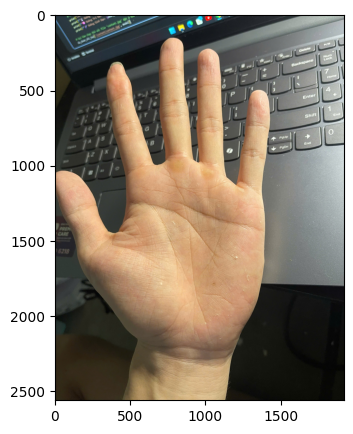


 KẾT QUẢ XEM CHỈ TAY 
 Tổng quan tướng tay: Tướng mạo phú quý tiềm ẩn, hậu vận phát đạt rực rỡ.

 Tình duyên (Tâm Đạo): Đường Tâm Đạo ngắn/mờ: Bạn sống lý trí, ít để tình cảm chi phối. Tình duyên đôi lúc lận đận vì ít bộc lộ cảm xúc ra ngoài.
 Công danh (Trí Đạo): Đường Trí Đạo ngắn: Thẳng thắn, quyết đoán, hợp làm kinh doanh hoặc các công việc thực tế, hành động nhanh gọn.
 Sức khỏe  (Sinh Đạo): Đường Sinh Đạo bình thường: Sức khỏe ổn định, cuộc sống ít gặp đại nạn, hậu vận an nhàn, bình yên bên gia đình.


In [ ]:

def xem_boi_sieu_toc(path_anh_khach_hang):
    FILE_LUU = "thay_boi_cnn.pth"
    if not os.path.exists(FILE_LUU):
        print("⚠️ Lỗi: Không tìm thấy file 'thay_boi_cnn.pth' ở thanh công cụ bên trái!")
        return

    if not os.path.exists(path_anh_khach_hang):
        print(f"⚠️ Không tìm thấy file ảnh '{path_anh_khach_hang}'. Bạn đã upload ảnh này lên chưa?")
        return

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


    model_KhaiTu = NetXemBoiCNN(num_classes=3).to(device)
    model_KhaiTu.load_state_dict(torch.load(FILE_LUU, map_location=device))
    model_KhaiTu.eval()


    img_hien_thi = Image.open(path_anh_khach_hang)
    plt.figure(figsize=(5, 5))
    plt.imshow(img_hien_thi)
    plt.axis('on')
    plt.show()


    transform_test = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    tensor = transform_test(img_hien_thi.convert("RGB")).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model_KhaiTu(tensor)
        res_tam = torch.argmax(pred['tam_dao'], dim=1).item()
        res_tri = torch.argmax(pred['tri_dao'], dim=1).item()
        res_sinh = torch.argmax(pred['sinh_dao'], dim=1).item()


    luan_giai = {
        'tam_dao': {
            0: "Đường Tâm Đạo ngắn/mờ: Bạn sống lý trí, ít để tình cảm chi phối. Tình duyên đôi lúc lận đận vì ít bộc lộ cảm xúc ra ngoài.",
            1: "Đường Tâm Đạo vừa vặn: Tình cảm hài hòa, cuộc sống hôn nhân tương lai tương đối êm ấm, gặp được người bạn đời biết sẻ chia.",
            2: "Đường Tâm Đạo dài sâu: Người cực kỳ giàu tình cảm, chung thủy sâu sắc. Tương lai tình duyên viên mãn nhưng đôi khi dễ bị lụy tình."
        },
        'tri_dao': {
            0: "Đường Trí Đạo ngắn: Thẳng thắn, quyết đoán, hợp làm kinh doanh hoặc các công việc thực tế, hành động nhanh gọn.",
            1: "Đường Trí Đạo cân đối: Tư duy logic tốt, có năng lực quản lý. Sự nghiệp tương lai vững vàng, càng về sau càng có lộc.",
            2: "Đường Trí Đạo dài sắc nét: Mưu lược hơn người, có tướng làm người đứng đầu. Đường quan lộ rộng mở, tài lộc dồi dào."
        },
        'sinh_dao': {
            0: "Đường Sinh Đạo ngắn: Thể chất giai đoạn đầu có thăng trầm, chỉ cần chăm chỉ rèn luyện thể thao sẽ kích hoạt sinh lực tiềm ẩn.",
            1: "Đường Sinh Đạo bình thường: Sức khỏe ổn định, cuộc sống ít gặp đại nạn, hậu vận an nhàn, bình yên bên gia đình.",
            2: "Đường Sinh Đạo dài cong rộng: Năng lượng tràn trề, số mệnh luôn có quý nhân phù trợ vững chắc. Đi xa lập nghiệp sẽ đại phú đại quý."
        }
    }
    tong_quan = ["Tướng mạo phú quý tiềm ẩn, hậu vận phát đạt rực rỡ.", "Số mệnh gặp hung hóa cát, có quý nhân chiếu mệnh.", "Bàn tay tự lực cánh sinh, tự tay tạo nên cơ đồ."]

    print("\n" + "="*50)
    print(" KẾT QUẢ XEM CHỈ TAY ")
    print("="*50)
    print(f" Tổng quan tướng tay: {random.choice(tong_quan)}\n")
    print(f" Tình duyên (Tâm Đạo): {luan_giai['tam_dao'][res_tam]}")
    print(f" Công danh (Trí Đạo): {luan_giai['tri_dao'][res_tri]}")
    print(f" Sức khỏe  (Sinh Đạo): {luan_giai['sinh_dao'][res_sinh]}")
    print("="*50)


xem_boi_sieu_toc('/content/taytrai.jpg')